In [1]:
import numpy as np
import sys 
import os
import h5py
import sys

import matplotlib
import matplotlib as mpl
import matplotlib.ticker as mticker
import matplotlib.pyplot as plt
matplotlib.use('agg')
from matplotlib.colors import LightSource, LogNorm

from astropy import constants as cons
from astropy import units as u

from LtU_get_property_notebook import get_particle_property_LTU
from Plot_observations import plot_obs_masses
from Plot_observations_nolabel import plot_obs_masses_nolabel
from Split_data import split_paired_array
from load_temps import *

import kdtree_smoothing as kd
import helpers
import arepo_package_notebook as arepo_package

%matplotlib inline

In [2]:
# Needed to load LaTeX on UVA's Rivanna: 
os.environ["MANPATH"] = "/standard/torrey-group/Share/texlive/2018/texmf-dist/doc/man:" + os.environ.get("MANPATH", "")
os.environ["INFOPATH"] = "/standard/torrey-group/Share/texlive/2018/texmf-dist/doc/info:" + os.environ.get("INFOPATH", "")
os.environ["PATH"] = "/standard/torrey-group/Share/texlive/2018/bin/x86_64-linux:/standard/torrey-group/Share/texlive/2018/texmf-dist:" + os.environ.get("PATH", "")

# Halo DM distribution

In [3]:
# Constrained

basePath = f'/project/torrey-group/jkho/LtU_accretion/Constrained/Bondi_constrained_AGN_fewseeds_stellar/output/'
z = 6
Ptype = 1

header = arepo_package.load_snapshot_header(basePath,z)
print(header.keys())
BoxSize = header['BoxSize']
DM_Mass = header['MassTable'][1]
h = 0.6774
DM_Pos,z = get_particle_property_LTU(basePath,'Coordinates',p_type=1, desired_redshift = z)

a = 1/(1+z)
DM_Pos *= a/h
DM_Pos_Constrained = DM_Pos - np.max(DM_Pos)/2 # Centering
DM_Masses_Constrained = np.ones(len(DM_Pos)) * DM_Mass * 1e10/h

HaloMasses,o=arepo_package.get_group_property(basePath,'GroupMass',z)
HaloPos,o=arepo_package.get_group_property(basePath,'GroupPos',z)
HaloRvir,o=arepo_package.get_group_property(basePath,'Group_R_Crit200',z) # Using same radius for all halos
target = np.argmax(HaloMasses)

Constrained_rvir = HaloRvir[target] * a/h
Constrained_Pos = HaloPos[target] * a/h - np.max(DM_Pos)/2
mask = (np.abs(DM_Pos_Constrained[:,0] - Constrained_Pos[0]) < 2*Constrained_rvir) & (np.abs(DM_Pos_Constrained[:,1] - Constrained_Pos[1]) < 2*Constrained_rvir) & (np.abs(DM_Pos_Constrained[:,2] - Constrained_Pos[2]) < 2*Constrained_rvir)
Constrained_target_pos = DM_Pos_Constrained[mask]
Constrained_target_mass = DM_Masses_Constrained[mask] 
Constrained_target_pos -= Constrained_Pos

# Zoom

basePath = f'/project/torrey-group/jkho/LtU_accretion/Zooms/Bondi_zoom_AGN/output/'
z = 6

header = arepo_package.load_snapshot_header(basePath,z)
print(header.keys())
BoxSize = header['BoxSize']
DM_Mass = header['MassTable'][1]
h = 0.6774
DM_Pos,z = get_particle_property_LTU(basePath,'Coordinates',p_type=1, desired_redshift = z)

a = 1/(1+z)
DM_Pos *= a/h
DM_Pos_Zooms = DM_Pos - np.max(DM_Pos)/2 # Centering
DM_Masses_Zooms = np.ones(len(DM_Pos)) * DM_Mass * 1e10/h

HaloMasses,o=arepo_package.get_group_property(basePath,'GroupMass',z)
HaloPos,o=arepo_package.get_group_property(basePath,'GroupPos',z)
HaloRvir,o=arepo_package.get_group_property(basePath,'Group_R_Crit200',z) # Using same radius for all halos
target = np.argmax(HaloMasses)

Zooms_rvir = HaloRvir[target] * a/h
Zooms_Pos = HaloPos[target] * a/h - np.max(DM_Pos)/2
mask = (np.abs(DM_Pos_Zooms[:,0] - Zooms_Pos[0]) < 2*Constrained_rvir) & (np.abs(DM_Pos_Zooms[:,1] - Zooms_Pos[1]) < 2*Constrained_rvir) & (np.abs(DM_Pos_Zooms[:,2] - Zooms_Pos[2]) < 2*Constrained_rvir)
Zooms_target_pos = DM_Pos_Zooms[mask]
Zooms_target_mass = DM_Masses_Zooms[mask]
Zooms_target_pos -= Zooms_Pos

# Small Uniform

basePath = f'/project/torrey-group/jkho/LtU_accretion/Low_mass_seeds/Bondi_lowmass_AGN_fewseeds_z127/output/'
z = 6

header = arepo_package.load_snapshot_header(basePath,z)
print(header.keys())
BoxSize = header['BoxSize']
DM_Mass = header['MassTable'][1]
h = 0.6774
DM_Pos,z = get_particle_property_LTU(basePath,'Coordinates',p_type=1, desired_redshift = z)

a = 1/(1+z)
DM_Pos *= a/h
DM_Pos_Small = DM_Pos - np.max(DM_Pos)/2 # Centering
DM_Masses_Small = np.ones(len(DM_Pos)) * DM_Mass * 1e10/h

HaloMasses,o=arepo_package.get_group_property(basePath,'GroupMass',z)
HaloPos,o=arepo_package.get_group_property(basePath,'GroupPos',z)
HaloRvir,o=arepo_package.get_group_property(basePath,'Group_R_Crit200',z) # Using same radius for all halos
target = np.argmax(HaloMasses)

L = np.max(DM_Pos)   # or use actual BoxSize if you have it

Small_rvir = HaloRvir[target] * a/h
Small_Pos = HaloPos[target] * a/h - L/2

# Compute wrapped separations (minimum image convention)
delta = DM_Pos_Small - Small_Pos
delta -= L * np.round(delta / L)

# Apply mask using wrapped distances
mask = (
    (np.abs(delta[:,0]) < 2*Constrained_rvir) &
    (np.abs(delta[:,1]) < 2*Constrained_rvir) &
    (np.abs(delta[:,2]) < 2*Constrained_rvir)
)

Small_target_pos = DM_Pos_Small[mask]
Small_target_mass = DM_Masses_Small[mask]

# Recompute wrapped positions for selected particles
delta_selected = Small_target_pos - Small_Pos
delta_selected -= L * np.round(delta_selected / L)

Small_target_pos = delta_selected

Desired redshift:  6
Output redshift:  6.0097596149373445
Output snapshot:  19
dict_keys(['BoxSize', 'MassTable', 'NumFilesPerSnapshot', 'NumPart_ThisFile', 'NumPart_Total', 'Redshift', 'Time'])
Desired redshift:  6
Output redshift:  6.0107573988449
Output snapshot:  19
dict_keys(['BoxSize', 'MassTable', 'NumFilesPerSnapshot', 'NumPart_ThisFile', 'NumPart_Total', 'Redshift', 'Time'])
Desired redshift:  6
Output redshift:  6.0107573988449
Output snapshot:  19
dict_keys(['BoxSize', 'MassTable', 'NumFilesPerSnapshot', 'NumPart_ThisFile', 'NumPart_Total', 'Redshift', 'Time'])


h 0.01956472468318348 4.318785009310056 0.6286141430035135


100%|██████████| 1000000/1000000 [00:43<00:00, 22997.92it/s]


h 0.028714811731443822 1.729319263107817 0.20433348230368725


100%|██████████| 1000000/1000000 [00:43<00:00, 23128.06it/s]


h 0.01944584556259068 0.7808815654956012 0.08597763616827267


100%|██████████| 1000000/1000000 [00:41<00:00, 24291.53it/s]


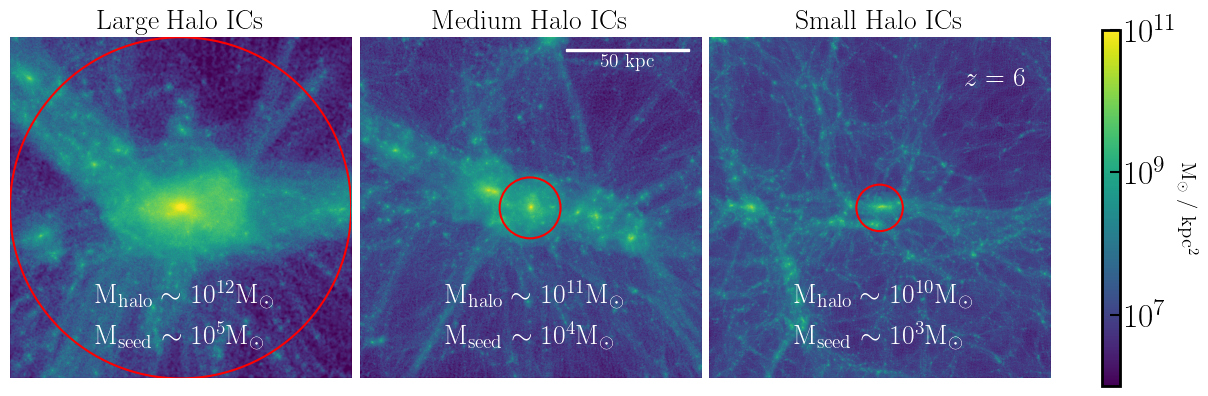

In [4]:
from matplotlib.cm import ScalarMappable
from matplotlib.patches import Circle
from mpl_toolkits.axes_grid1.anchored_artists import AnchoredSizeBar
import matplotlib.font_manager as fm

# --- Plotting Params ---
vmin = 1e6
vmax = 1e11
cmap = 'viridis'
pixel_scale = 500 # Larger = finer resolution

sm = ScalarMappable(norm=LogNorm(vmin=vmin, vmax=vmax), cmap=cmap)
sm.set_array([])

fig,axs = plt.subplots(1,3,figsize=(12,8), constrained_layout=True)

# --- Constrained ---
L = np.max(Constrained_target_pos)

image = kd.simple_makepic(
    Constrained_target_pos, Constrained_target_mass, image_size = L, pixel_size=L/pixel_scale
)

axs[0].imshow(image.T,cmap=cmap,norm=LogNorm(vmin=vmin, vmax=vmax),extent=[0, L, 0, L])

p = Circle(
    (L/2,L/2), 
    Constrained_rvir,
    fill=False,
    edgecolor='red',
    linewidth=1.5
)
axs[0].add_artist(p)

# --- Zooms ---

L = np.max(Zooms_target_pos)

image = kd.simple_makepic(
    Zooms_target_pos, Zooms_target_mass, image_size = L, pixel_size=L/pixel_scale
)

axs[1].imshow(image.T,cmap=cmap,norm=LogNorm(vmin=vmin, vmax=vmax),extent=[0, L, 0, L])

p = Circle(
    (L/2,L/2), 
    Zooms_rvir/2,
    fill=False,
    edgecolor='red',
    linewidth=1.5
)
axs[1].add_artist(p)

# --- Small Uniform ---

L = np.max(Small_target_pos)

image = kd.simple_makepic(
    Small_target_pos, Small_target_mass, image_size = L, pixel_size=L/pixel_scale
)

axs[2].imshow(image.T,cmap=cmap,norm=LogNorm(vmin=vmin, vmax=vmax),extent=[0, L, 0, L])

p = Circle(
    (L/2,L/2),
    Small_rvir,
    fill=False,
    edgecolor='red',
    linewidth=1.5
)
axs[2].add_artist(p)

for ax in axs.flatten():
    ax.axis('off')

# --- Scale bar for middle panel ---
fontprops = fm.FontProperties(size=14)

scalebar = AnchoredSizeBar(
    axs[1].transData,
    50,                 # length of scale bar in data units (kpc)
    '50 kpc',           # label
    'upper right',       # location
    pad=0.5,
    color='white',
    frameon=False,
    size_vertical=L/200, # thickness of bar
    fontproperties=fontprops
)

axs[1].add_artist(scalebar)

axs[0].set_title('Large Halo ICs',size=20)
axs[1].set_title('Medium Halo ICs',size=20)
axs[2].set_title('Small Halo ICs',size=20)
axs[0].text(L/4,L/4.5,r'$\rm M_{halo}\sim 10^{12} M_\odot$',fontsize=20,color='white')
axs[1].text(L/4,L/4.5,r'$\rm M_{halo}\sim 10^{11} M_\odot$',fontsize=20,color='white')
axs[2].text(L/4,L/4.5,r'$\rm M_{halo}\sim 10^{10} M_\odot$',fontsize=20,color='white')
axs[0].text(L/4,L/10,r'$\rm M_{seed}\sim 10^{5} M_\odot$',fontsize=20,color='white')
axs[1].text(L/4,L/10,r'$\rm M_{seed}\sim 10^{4} M_\odot$',fontsize=20,color='white')
axs[2].text(L/4,L/10,r'$\rm M_{seed}\sim 10^{3} M_\odot$',fontsize=20,color='white')
axs[2].text(3*L/4,6*L/7,r'$z=6$',fontsize=20,color='white')

cbar = fig.colorbar(sm, ax=axs,shrink=0.45)
cbar.set_label(r'$\rm M_\odot~/~kpc^2$', rotation=270, labelpad=15, fontsize=15)

# fig.tight_layout()
fig.savefig('Plots/All_halos_smoothed_simple_scale.png',bbox_inches='tight')

# Halo growth histories

In [5]:
filename = "output/halo_growth_histories.hdf5"

with h5py.File(filename, "r") as f:
    redshifts = f["redshift"][:]

    Con_Mass = f["Con_Mass"][:]
    Zoom_Mass = f["Zoom_Mass"][:]
    Low_Mass = f["Low_Mass"][:]
    R_Mass = f["R_Mass"][:]

    Con_StellarMass = f["Con_StellarMass"][:]
    Zoom_StellarMass = f["Zoom_StellarMass"][:]
    Low_StellarMass = f["Low_StellarMass"][:]
    R_StellarMass = f["R_StellarMass"][:]

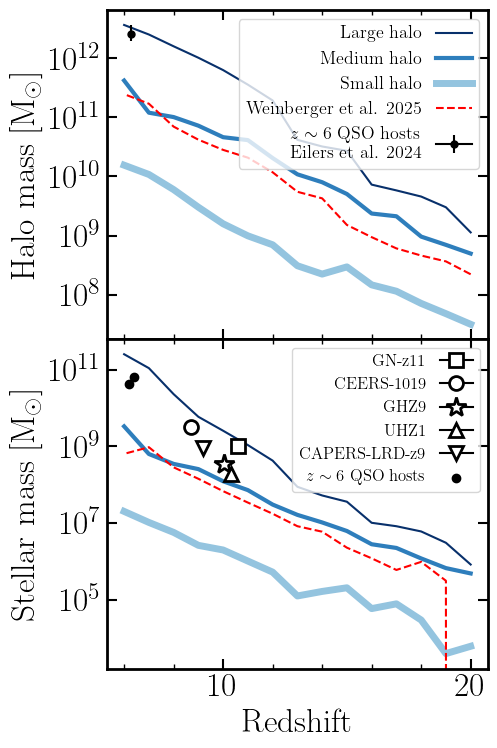

In [6]:
# Loading in digitized observational data
JWST_AGN = [10.317880794701985, 183389508.09170106, 10.019867549668874, 339519089.4769204, 10.6158940397351, 1009520695.0107281, 9.185430463576157, 875763480.9087172, 8.70860927152318, 3147330763.950849]
JWST_x,JWST_y = split_paired_array(JWST_AGN)

QSO_Mstar = [6.2052980132450335, 42621588290.15325, 6.384105960264901, 65285211411.27847]
QSO_Mstar_x,QSO_Mstar_y = split_paired_array(QSO_Mstar)

# First data point is measurement, second and third are errorbars
QSO_Mhalo = [6.296296296296296, 2604365475146.108, 6.237037037037037, 1949336850757.5593, 6.237037037037037, 3625333554791.3174]
QSO_Mhalo_x,QSO_Mhalo_y = split_paired_array(QSO_Mhalo)
y_low = QSO_Mhalo_y[1]
y_high = QSO_Mhalo_y[2]

yerr = np.array([
    [QSO_Mhalo_y[0] - y_low],     # lower offset
    [y_high - QSO_Mhalo_y[0]]     # upper offset
])

# Get the colormap
cmap = plt.get_cmap("Blues")

# Pick 3 distinct shades (avoid extremes for visibility)
colors = cmap(np.linspace(0.4, 1.0, 3))

fig,axs = plt.subplots(2,1,figsize=(5.5,8),sharex=True)

axs[0].plot(redshifts, Con_Mass, label='Large halo', color=colors[2])
axs[0].plot(redshifts, Zoom_Mass, label='Medium halo', color=colors[1],lw = 3)
axs[0].plot(redshifts, Low_Mass, label='Small halo', color=colors[0],lw = 5)
axs[0].plot(redshifts, R_Mass, label='Weinberger et al. 2025', ls='--', color='red')

axs[1].plot(redshifts, Con_StellarMass, color=colors[2])
axs[1].plot(redshifts, Zoom_StellarMass, color=colors[1],lw = 3)
axs[1].plot(redshifts, Low_StellarMass, color=colors[0],lw = 5)
axs[1].plot(redshifts, R_StellarMass, ls='--', color='red')

axs[1].plot(JWST_x[2],JWST_y[2],marker='s',color='black',ms=10,label='GN-z11',markerfacecolor='white',markeredgecolor='black',markeredgewidth=2,zorder=1000)
axs[1].plot(JWST_x[4],JWST_y[4],marker='o',color='black',ms=10,label='CEERS-1019',markerfacecolor='white',markeredgecolor='black',markeredgewidth=2,zorder=1000)
axs[1].plot(JWST_x[1],JWST_y[1],marker='*',color='black',ms=15,label='GHZ9',markerfacecolor='white',markeredgecolor='black',markeredgewidth=2,zorder=1000)
axs[1].plot(JWST_x[0],JWST_y[0],marker='^',color='black',ms=10,label='UHZ1',markerfacecolor='white',markeredgecolor='black',markeredgewidth=2,zorder=1000)
axs[1].plot(JWST_x[3],JWST_y[3],marker='v',color='black',ms=10,label='CAPERS-LRD-z9',markerfacecolor='white',markeredgecolor='black',markeredgewidth=2,zorder=1000)

axs[0].errorbar(QSO_Mhalo_x[0],QSO_Mhalo_y[0],yerr = yerr,
                label = '$z\\sim6$ QSO hosts\nEilers et al. 2024',color = 'k',marker = '.',ms = 10)
axs[1].scatter(QSO_Mstar_x,QSO_Mstar_y,label = r'$z\sim6$ QSO hosts',color = 'k')

axs[0].set_yscale("log")
axs[1].set_yscale("log")
axs[1].set_xlabel("Redshift")
axs[0].set_ylabel(r"Halo mass [M$_\odot$]")
axs[1].set_ylabel(r"Stellar mass [M$_\odot$]")

axs[0].legend(fontsize=13,markerfirst=False)
axs[1].legend(fontsize=12,markerfirst=False)

axs[0].set_yticks([1e8,1e9,1e10,1e11,1e12],labels = [r'$10^8$',r'$10^9$',r'$10^{10}$',r'$10^{11}$',r'$10^{12}$'])
axs[1].set_yticks([1e5,1e7,1e9,1e11],labels = [r'$10^5$',r'$10^7$',r'$10^9$',r'$10^{11}$'])

fig.tight_layout()
fig.subplots_adjust(hspace=0)
fig.savefig('Plots/Halo_stellar_mass_comparison.png',bbox_inches='tight')

# 2x2 BH mass/luminosity histories

In [7]:
files = ['Constrained','Zooms','Low_mass_seeds']
sim=0      # --- Change this here! --- #
file = files[sim]

h = 0.6774
eps = 0.1 # radiative efficiency
c = cons.c.cgs.value
Mseeds = np.array([1e-05,1.25e-06,1.5625e-07])*1e10/h
    
redshifts = np.arange(18, 5, -1)

with h5py.File(f"output/{file}_25.hdf5", "r") as f:
    
    Bondi_AGN_NS_mass = f['AGN_NS']['Bondi']['Masses'][2:]
    Bondi_AGN_S_mass = f['AGN_S']['Bondi']['Masses'][2:]
    Bondi_NAGN_S_mass = f['NAGN_S']['Bondi']['Masses'][2:]
    Bondi_NAGN_NS_mass = f['NAGN_NS']['Bondi']['Masses'][2:]

    FF_AGN_NS_mass = f['AGN_NS']['FF']['Masses'][2:]
    FF_AGN_S_mass = f['AGN_S']['FF']['Masses'][2:]
    FF_NAGN_S_mass = f['NAGN_S']['FF']['Masses'][2:]
    FF_NAGN_NS_mass = f['NAGN_NS']['FF']['Masses'][2:]

    modFF_AGN_NS_mass = f['AGN_NS']['modFF']['Masses'][2:]
    modFF_AGN_S_mass = f['AGN_S']['modFF']['Masses'][2:]
    modFF_NAGN_S_mass = f['NAGN_S']['modFF']['Masses'][2:]
    modFF_NAGN_NS_mass = f['NAGN_NS']['modFF']['Masses'][2:]

    Bondi_AGN_NS_accretion = f['AGN_NS']['Bondi']['Accretion_growth'][2:] + Mseeds[sim]
    Bondi_AGN_S_accretion = f['AGN_S']['Bondi']['Accretion_growth'][2:] + Mseeds[sim]
    Bondi_NAGN_S_accretion = f['NAGN_S']['Bondi']['Accretion_growth'][2:] + Mseeds[sim]
    Bondi_NAGN_NS_accretion = f['NAGN_NS']['Bondi']['Accretion_growth'][2:] + Mseeds[sim]

    FF_AGN_NS_accretion = f['AGN_NS']['FF']['Accretion_growth'][2:] + Mseeds[sim]
    FF_AGN_S_accretion = f['AGN_S']['FF']['Accretion_growth'][2:] + Mseeds[sim]
    FF_NAGN_S_accretion = f['NAGN_S']['FF']['Accretion_growth'][2:] + Mseeds[sim]
    FF_NAGN_NS_accretion = f['NAGN_NS']['FF']['Accretion_growth'][2:] + Mseeds[sim]

    modFF_AGN_NS_accretion = f['AGN_NS']['modFF']['Accretion_growth'][2:] + Mseeds[sim]
    modFF_AGN_S_accretion = f['AGN_S']['modFF']['Accretion_growth'][2:] + Mseeds[sim]
    modFF_NAGN_S_accretion = f['NAGN_S']['modFF']['Accretion_growth'][2:] + Mseeds[sim]
    modFF_NAGN_NS_accretion = f['NAGN_NS']['modFF']['Accretion_growth'][2:] + Mseeds[sim]

    Bondi_AGN_NS_mdots = f['AGN_NS']['Bondi']['Mdots'][2:] * u.Msun.to(u.g)/(u.Gyr.to(u.s))
    Bondi_AGN_S_mdots = f['AGN_S']['Bondi']['Mdots'][2:] * u.Msun.to(u.g)/(u.Gyr.to(u.s))
    Bondi_NAGN_S_mdots = f['NAGN_S']['Bondi']['Mdots'][2:] * u.Msun.to(u.g)/(u.Gyr.to(u.s))
    Bondi_NAGN_NS_mdots = f['NAGN_NS']['Bondi']['Mdots'][2:] * u.Msun.to(u.g)/(u.Gyr.to(u.s))

    FF_AGN_NS_mdots = f['AGN_NS']['FF']['Mdots'][2:] * u.Msun.to(u.g)/(u.Gyr.to(u.s))
    FF_AGN_S_mdots = f['AGN_S']['FF']['Mdots'][2:] * u.Msun.to(u.g)/(u.Gyr.to(u.s))
    FF_NAGN_S_mdots = f['NAGN_S']['FF']['Mdots'][2:] * u.Msun.to(u.g)/(u.Gyr.to(u.s))
    FF_NAGN_NS_mdots = f['NAGN_NS']['FF']['Mdots'][2:] * u.Msun.to(u.g)/(u.Gyr.to(u.s))

    modFF_AGN_NS_mdots = f['AGN_NS']['modFF']['Mdots'][2:] * u.Msun.to(u.g)/(u.Gyr.to(u.s))
    modFF_AGN_S_mdots = f['AGN_S']['modFF']['Mdots'][2:] * u.Msun.to(u.g)/(u.Gyr.to(u.s))
    modFF_NAGN_S_mdots = f['NAGN_S']['modFF']['Mdots'][2:] * u.Msun.to(u.g)/(u.Gyr.to(u.s))
    modFF_NAGN_NS_mdots = f['NAGN_NS']['modFF']['Mdots'][2:] * u.Msun.to(u.g)/(u.Gyr.to(u.s))

    Bondi_AGN_NS_edd = f['AGN_NS']['Bondi']['Edd'][2:] * u.Msun.to(u.g)/(u.Gyr.to(u.s)) * eps * c**2
    Bondi_AGN_S_edd = f['AGN_S']['Bondi']['Edd'][2:] * u.Msun.to(u.g)/(u.Gyr.to(u.s)) * eps * c**2
    Bondi_NAGN_S_edd = f['NAGN_S']['Bondi']['Edd'][2:] * u.Msun.to(u.g)/(u.Gyr.to(u.s)) * eps * c**2
    Bondi_NAGN_NS_edd = f['NAGN_NS']['Bondi']['Edd'][2:] * u.Msun.to(u.g)/(u.Gyr.to(u.s)) * eps * c**2

    FF_AGN_NS_edd = f['AGN_NS']['FF']['Edd'][2:] * u.Msun.to(u.g)/(u.Gyr.to(u.s)) * eps * c**2
    FF_AGN_S_edd = f['AGN_S']['FF']['Edd'][2:] * u.Msun.to(u.g)/(u.Gyr.to(u.s)) * eps * c**2
    FF_NAGN_S_edd = f['NAGN_S']['FF']['Edd'][2:] * u.Msun.to(u.g)/(u.Gyr.to(u.s)) * eps * c**2
    FF_NAGN_NS_edd = f['NAGN_NS']['FF']['Edd'][2:] * u.Msun.to(u.g)/(u.Gyr.to(u.s)) * eps * c**2

    modFF_AGN_NS_edd = f['AGN_NS']['modFF']['Edd'][2:] * u.Msun.to(u.g)/(u.Gyr.to(u.s)) * eps * c**2
    modFF_AGN_S_edd = f['AGN_S']['modFF']['Edd'][2:] * u.Msun.to(u.g)/(u.Gyr.to(u.s)) * eps * c**2
    modFF_NAGN_S_edd = f['NAGN_S']['modFF']['Edd'][2:] * u.Msun.to(u.g)/(u.Gyr.to(u.s)) * eps * c**2
    modFF_NAGN_NS_edd = f['NAGN_NS']['modFF']['Edd'][2:] * u.Msun.to(u.g)/(u.Gyr.to(u.s)) * eps * c**2

Bondi_AGN_NS_lum = Bondi_AGN_NS_mdots * eps * c**2
Bondi_AGN_S_lum = Bondi_AGN_S_mdots * eps * c**2
Bondi_NAGN_S_lum = Bondi_NAGN_S_mdots * eps * c**2
Bondi_NAGN_NS_lum = Bondi_NAGN_NS_mdots * eps * c**2

FF_AGN_NS_lum = FF_AGN_NS_mdots * eps * c**2
FF_AGN_S_lum = FF_AGN_S_mdots * eps * c**2
FF_NAGN_S_lum = FF_NAGN_S_mdots * eps * c**2
FF_NAGN_NS_lum = FF_NAGN_NS_mdots * eps * c**2

modFF_AGN_NS_lum = modFF_AGN_NS_mdots * eps * c**2
modFF_AGN_S_lum = modFF_AGN_S_mdots * eps * c**2
modFF_NAGN_S_lum = modFF_NAGN_S_mdots * eps * c**2
modFF_NAGN_NS_lum = modFF_NAGN_NS_mdots * eps * c**2

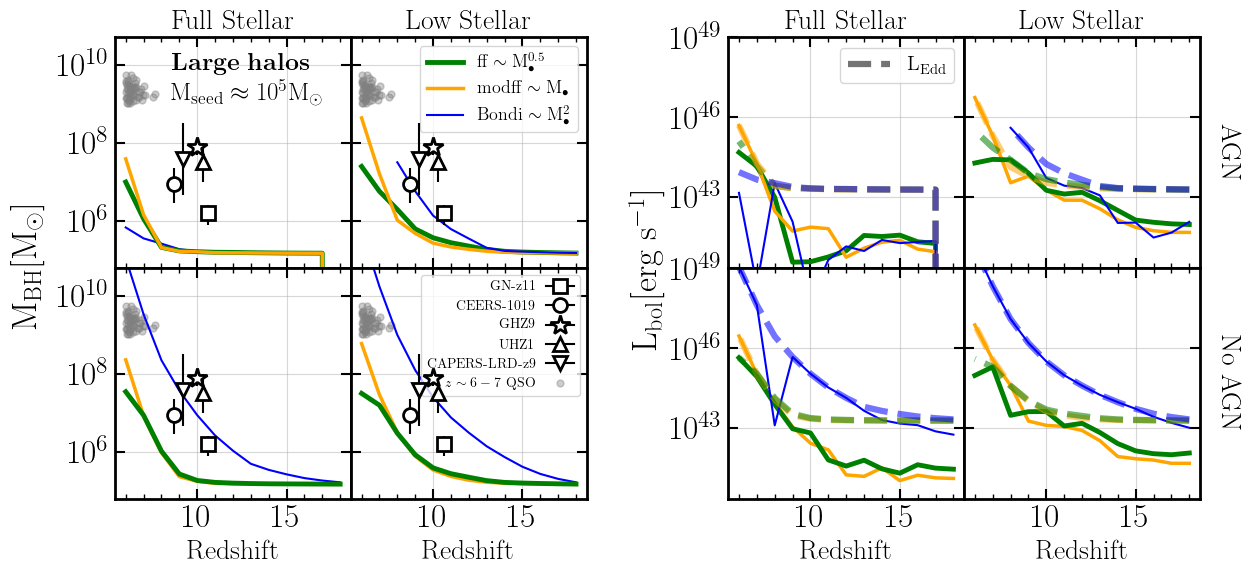

In [8]:
fig = plt.figure(figsize=(14,6))

# Outer grid: 1 row, 2 columns
outer = fig.add_gridspec(1, 2, wspace=0.3)

# LEFT: your original 2x2 panel
left = outer[0].subgridspec(2, 2, wspace=0.0, hspace=0.0)
axs_left = left.subplots(sharey=True,sharex=True)

# RIGHT: empty 2x2 panel
right = outer[1].subgridspec(2, 2, wspace=0.0, hspace=0.0)
axs_right = right.subplots(sharey=True,sharex=True)

# Turn off the empty axes (so they don't show frames/ticks)
# for ax in axs_empty.flatten():
#     ax.axis('off')

Bondi_lw = 1.5
modff_lw = 2.5
ff_lw = 3.5

# ======= Left panel =======

axs_left[0,0].plot(redshifts,Bondi_AGN_S_mass,color='blue',lw = Bondi_lw)
axs_left[0,0].plot(redshifts,FF_AGN_S_mass,color='green',lw = ff_lw)
axs_left[0,0].plot(redshifts,modFF_AGN_S_mass,color='orange',lw = modff_lw)

axs_left[0,1].plot(redshifts,FF_AGN_NS_mass,color='green',label = r'ff $\sim\rm M_{\bullet}^{0.5}$',lw = ff_lw)
axs_left[0,1].plot(redshifts,modFF_AGN_NS_mass,color='orange',label = r'modff $\sim\rm M_{\bullet}$',lw = modff_lw)
if sim == 0:
    axs_left[0,1].plot(redshifts[:-2],Bondi_AGN_NS_mass[:-2],color='blue',label = r'Bondi $\sim\rm M_{\bullet}^2$',lw = Bondi_lw)
else:
    axs_left[0,1].plot(redshifts,Bondi_AGN_NS_mass,color='blue',label = r'Bondi $\sim\rm M_{\bullet}^2$',lw = Bondi_lw)

axs_left[1,0].plot(redshifts,Bondi_NAGN_S_mass,color='blue',lw = Bondi_lw)
axs_left[1,0].plot(redshifts,modFF_NAGN_S_mass,color='orange',lw = modff_lw)
axs_left[1,0].plot(redshifts,FF_NAGN_S_mass,color='green',lw = ff_lw)

axs_left[1,1].plot(redshifts,Bondi_NAGN_NS_mass,color='blue',lw = Bondi_lw)
axs_left[1,1].plot(redshifts,modFF_NAGN_NS_mass,color='orange',lw = modff_lw)
axs_left[1,1].plot(redshifts,FF_NAGN_NS_mass,color='green',lw = ff_lw)

if sim==2:
    axs_left[1,1].plot(redshifts,Bondi_NAGN_NS_accretion,color='blue',ls='--',lw = Bondi_lw)
    axs_left[1,1].plot(redshifts,modFF_NAGN_NS_accretion,color='orange',ls='--',lw = modff_lw)
    axs_left[1,1].plot(redshifts,FF_NAGN_NS_accretion,color='green',ls='--',lw = ff_lw)
    
    axs_left[0,1].plot(redshifts,Bondi_AGN_NS_accretion,color='blue',ls='--',lw = Bondi_lw)
    axs_left[0,1].plot(redshifts,modFF_AGN_NS_accretion,color='orange',ls='--',lw = modff_lw)
    axs_left[0,1].plot(redshifts,FF_AGN_NS_accretion,color='green',ls='--',lw = ff_lw)

    axs_left[1,1].plot([], [], ls='--', color='k', label='Accretion growth')
    axs_left[1,1].legend(fontsize=13,loc='upper right')

if file == 'Low_mass_seeds':
    fig.text(0.165,0.825,r'$\bf{Small~halos}$',size=18)
    fig.text(0.165,0.775,r'$\rm M_{seed} \approx 10^3M_\odot$',size=18)
elif file == 'Constrained':
    fig.text(0.165,0.825,r'$\bf{Large~halos}$',size=18)
    fig.text(0.165,0.775,r'$\rm M_{seed} \approx 10^5M_\odot$',size=18)
elif file == 'Zooms':
    fig.text(0.165,0.825,r'$\bf{Medium~halos}$',size=18)
    fig.text(0.165,0.775,r'$\rm \ M_{seed} \approx 10^4M_\odot$',size=18)

axs_left[0,0].set_title('Full Stellar',size=20)
axs_left[0,1].set_title('Low Stellar',size=20)

axs_left[1,0].set_xlabel('Redshift',size=20)
axs_left[1,1].set_xlabel('Redshift',size=20)

axs_left[0,1].legend(fontsize=13)
    
fig.supylabel(r'$\rm M_{BH} [M_\odot]$',x=0.05,size=25)    

if sim == 0:
    for ax in axs_left.flatten():
        if ax == axs_left.flatten()[1]:
            plot_obs_masses_nolabel(ax)
        else:
            plot_obs_masses(ax)
        ax.set_ylim(1e4,1e12)
        
    axs_left[1,1].legend(fontsize=10,markerfirst=False)

for ax in axs_left.flat:
    ax.set_yscale('log')
    ax.grid(alpha = 0.5)

# ======= Right panel =======

# Actual luminosities
axs_right[0,0].plot(redshifts,FF_AGN_S_lum,color='green',lw = ff_lw)
axs_right[0,0].plot(redshifts,modFF_AGN_S_lum,color='orange',lw = modff_lw)
axs_right[0,0].plot(redshifts,Bondi_AGN_S_lum,color='blue',lw = Bondi_lw)

axs_right[0,1].plot(redshifts,modFF_AGN_NS_lum,label = r'modff $\sim\rm M_{\bullet}$',color='orange',lw = modff_lw)
axs_right[0,1].plot(redshifts,FF_AGN_NS_lum,label = r'ff $\sim\rm M_{\bullet}^{0.5}$',color='green',lw = ff_lw)
if sim == 0:
    axs_right[0,1].plot(redshifts[:-2],Bondi_AGN_NS_lum[:-2],label = r'Bondi $\sim\rm M_{\bullet}^2$',color='blue',lw = Bondi_lw)
else:
    axs_right[0,1].plot(redshifts,Bondi_AGN_NS_lum,label = r'Bondi $\sim\rm M_{\bullet}^2$',color='blue',lw = Bondi_lw)

axs_right[1,0].plot(redshifts,modFF_NAGN_S_lum,color='orange',lw = modff_lw)
axs_right[1,0].plot(redshifts,FF_NAGN_S_lum,color='green',lw = ff_lw)
axs_right[1,0].plot(redshifts,Bondi_NAGN_S_lum,color='blue',lw = Bondi_lw)

axs_right[1,1].plot(redshifts,modFF_NAGN_NS_lum,color='orange',lw = modff_lw)
axs_right[1,1].plot(redshifts,FF_NAGN_NS_lum,color='green',lw = ff_lw)
axs_right[1,1].plot(redshifts,Bondi_NAGN_NS_lum,color='blue',lw = Bondi_lw)

# Eddington luminosities
axs_right[0,0].plot(redshifts,FF_AGN_S_edd,color='green',ls = '--',lw = 4.5,alpha=0.55)
axs_right[0,0].plot(redshifts,modFF_AGN_S_edd,color='orange',ls = '--',lw = 4.5,alpha=0.55)
axs_right[0,0].plot(redshifts,Bondi_AGN_S_edd,color='blue',ls = '--',lw = 4.5,alpha=0.55)

axs_right[0,1].plot(redshifts,modFF_AGN_NS_edd,color='orange',ls = '--',lw = 4.5,alpha=0.55)
axs_right[0,1].plot(redshifts,FF_AGN_NS_edd,color='green',ls = '--',lw = 4.5,alpha=0.55)
if sim == 0:
    axs_right[0,1].plot(redshifts[:-2],Bondi_AGN_NS_edd[:-2],color='blue',ls = '--',lw = 4.5,alpha=0.55)
else:
    axs_right[0,1].plot(redshifts,Bondi_AGN_NS_edd,color='blue',ls = '--',lw = 4.5,alpha=0.55)

axs_right[1,0].plot(redshifts,modFF_NAGN_S_edd,color='orange',ls = '--',lw = 4.5,alpha=0.55)
axs_right[1,0].plot(redshifts,FF_NAGN_S_edd,color='green',ls = '--',lw = 4.5,alpha=0.55)
axs_right[1,0].plot(redshifts,Bondi_NAGN_S_edd,color='blue',ls = '--',lw = 4.5,alpha=0.55)

axs_right[1,1].plot(redshifts,modFF_NAGN_NS_edd,color='orange',ls = '--',lw = 4.5,alpha=0.55)
axs_right[1,1].plot(redshifts,FF_NAGN_NS_edd,color='green',ls = '--',lw = 4.5,alpha=0.55)
axs_right[1,1].plot(redshifts,Bondi_NAGN_NS_edd,color='blue',ls = '--',lw = 4.5,alpha=0.55)

axs_right[0,0].plot([], [], ls='--', lw=4.5, alpha=0.55, color='k', label=r'$\rm L_{Edd}$')

for ax in axs_right.flat:
    ax.set_yscale('log')
    ax.grid(alpha = 0.5)

if sim == 2:
    mass_ticks = [1e3,1e4]

    for ax in axs_left.flat:
        ax.set_yticks(mass_ticks)
        ax.yaxis.set_major_formatter(mticker.LogFormatterMathtext())
        # ax.set_ylim(9e2,2.5e4)
elif sim == 0:
    for ax in axs_left.flat:
        ax.set_ylim(6e4,5e10)
    for ax in axs_right.flat:
        ax.set_ylim(2e40,1e49)

axs_right[0,0].set_title('Full Stellar',size=20)
axs_right[0,1].set_title('Low Stellar',size=20)
axs_right[1,0].set_xlabel('Redshift',size=20)
axs_right[1,1].set_xlabel('Redshift',size=20)
axs_right[0,1].set_ylabel('AGN',rotation=270,labelpad=30,size=20)
axs_right[0,1].yaxis.set_label_position("right")
axs_right[1,1].set_ylabel('No AGN',rotation=270,labelpad=30,size=20)
axs_right[1,1].yaxis.set_label_position("right")
axs_right[0,0].set_ylabel(r'$\rm L_{bol} [erg~s^{-1}]$',y=0.0,size=25)
# axs_right[1,0].set_ylabel(r'$\rm L_{Bol} [erg/s]$')
axs_right[0,0].legend(fontsize=15, loc=1)

fig.savefig(f'Plots/Double_{file}_4panel_BH_growth_comparison_z20.png',bbox_inches='tight')

# Lenient vs. Strict seeding

In [9]:
# Loading from saved file:

filename = "output/lenient_bh_growth_SMHM10.hdf5" # "output/lenient_bh_growth_z20.hdf5" # "output/lenient_bh_growth.hdf5"

boxes = ['Low_mass_seeds', 'Zooms', 'Constrained']
modes = ['strict', 'lenient']
models = ['Bondi', 'FreeFall', 'modFreeFall']

Masses_Bondi = []
Masses_FF = []
Masses_modFF = []

QM_Bondi = []
QM_FF = []
QM_modFF = []

QME_Bondi = []
QME_FF = []
QME_modFF = []

with h5py.File(filename, 'r') as f:

    redshifts = f['Redshifts'][:]

    for box in boxes:
        for mode in modes:

            grp = f[f"{box}/{mode}"]

            Masses_Bondi.append(grp['Bondi/Mass'][:])
            Masses_FF.append(grp['FreeFall/Mass'][:])
            Masses_modFF.append(grp['modFreeFall/Mass'][:])

            QM_Bondi.append(grp['Bondi/QM_growth'][:])
            QM_FF.append(grp['FreeFall/QM_growth'][:])
            QM_modFF.append(grp['modFreeFall/QM_growth'][:])

            QME_Bondi.append(grp['Bondi/QM_energy'][:])
            QME_FF.append(grp['FreeFall/QM_energy'][:])
            QME_modFF.append(grp['modFreeFall/QM_energy'][:])

Masses_Bondi = np.array(Masses_Bondi)
Masses_FF = np.array(Masses_FF)
Masses_modFF = np.array(Masses_modFF)

QM_Bondi = np.array(QM_Bondi)
QM_FF = np.array(QM_FF)
QM_modFF = np.array(QM_modFF)

QME_Bondi = np.array(QME_Bondi)
QME_FF = np.array(QME_FF)
QME_modFF = np.array(QME_modFF)

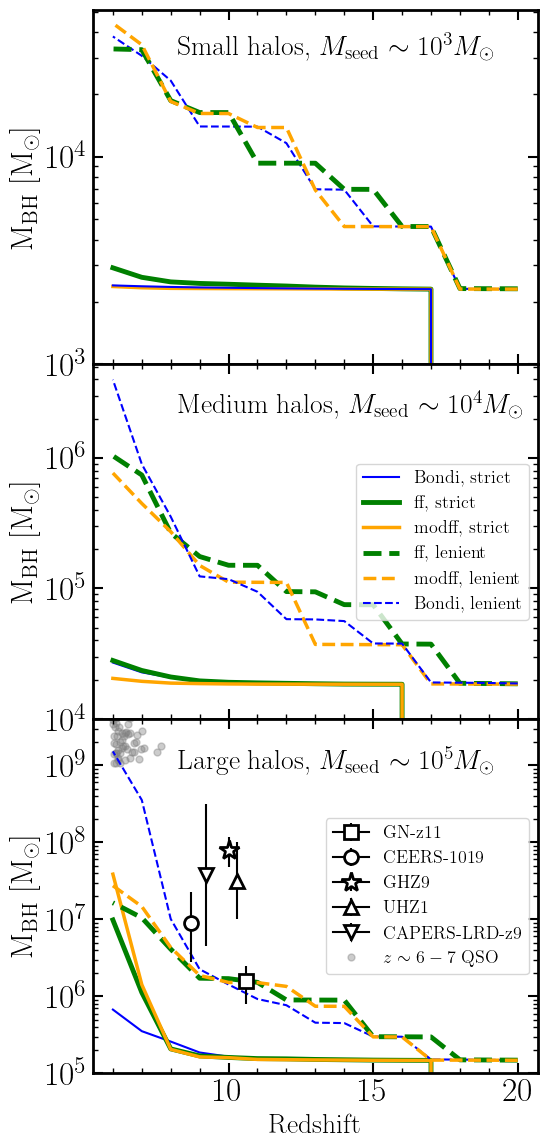

In [10]:
fig,axs = plt.subplots(3,1,figsize=(6,12),sharex=True)

Bondi_lw = 1.5
modff_lw = 2.5
ff_lw = 3.5

axs[0].plot(redshifts,Masses_FF[0],label = 'ff, strict',color='green',lw = ff_lw)
axs[0].plot(redshifts,Masses_modFF[0],label = 'modff, strict',color='orange',lw = modff_lw)
axs[0].plot(redshifts,Masses_Bondi[0],label = 'Bondi, strict',color='blue',lw = Bondi_lw)

axs[0].plot(redshifts,Masses_Bondi[1],ls = '--',color='blue',lw = Bondi_lw)
axs[0].plot(redshifts,Masses_FF[1],ls = '--',color='green',lw = ff_lw)
axs[0].plot(redshifts,Masses_modFF[1],ls = '--',color='orange',lw = modff_lw)

axs[1].plot(redshifts,Masses_Bondi[2],label = 'Bondi, strict',color='blue',lw = Bondi_lw)
axs[1].plot(redshifts,Masses_FF[2],label = 'ff, strict',color='green',lw = ff_lw)
axs[1].plot(redshifts,Masses_modFF[2],label = 'modff, strict',color='orange',lw = modff_lw)

axs[1].plot(redshifts,Masses_FF[3],label = 'ff, lenient',ls = '--',color='green',lw = ff_lw)
axs[1].plot(redshifts,Masses_modFF[3],label = 'modff, lenient',ls = '--',color='orange',lw = modff_lw)
axs[1].plot(redshifts,Masses_Bondi[3],label = 'Bondi, lenient',ls = '--',color='blue',lw = Bondi_lw)

axs[2].plot(redshifts,Masses_Bondi[4],color='blue',lw = Bondi_lw)
axs[2].plot(redshifts,Masses_FF[4],color='green',lw = ff_lw)
axs[2].plot(redshifts,Masses_modFF[4],color='orange',lw = modff_lw)

axs[2].plot(redshifts,Masses_Bondi[5],ls = '--',color='blue',lw = Bondi_lw)
axs[2].plot(redshifts,Masses_FF[5],ls = '--',color='green',lw = ff_lw)
axs[2].plot(redshifts,Masses_modFF[5],ls = '--',color='orange',lw = modff_lw)

axs[0].plot([],[],ls = '--',label = 'Lenient seeding',color='k')

axs[0].text(8.25,3.1e4,r'Small halos, $M_{\rm seed}\sim 10^3 M_\odot$',fontsize=20)
axs[1].text(8.25,2.2e6,r'Medium halos, $M_{\rm seed}\sim 10^4 M_\odot$',fontsize=20)
axs[2].text(8.25,9e8,r'Large halos, $M_{\rm seed}\sim 10^5 M_\odot$',fontsize=20)

# Setting y axis ticks
for ax in axs:
    ax.set_yscale('log')
    ax.set_ylabel(r'$\rm M_{BH}~[M_\odot]$',fontsize=22)
    
# axs[0].set_yticks([3e3,1e4,4e4],labels = [r'$3\times10^3$',r'$10^4$',r'$4\times10^4$'])
mass_ticks = [1e3,1e4]
axs[0].set_yticks(mass_ticks)
axs[0].yaxis.set_major_formatter(mticker.LogFormatterMathtext())
ax.set_ylim(9e2,2.5e4)

axs[1].set_yticks([1e4,1e5,1e6],labels = [r'$10^4$',r'$10^5$',r'$10^6$'])
axs[2].set_yticks([1e5,1e6,1e7,1e8,1e9],labels = [r'$10^5$',r'$10^6$',r'$10^7$',r'$10^8$',r'$10^9$'])
axs[2].set_ylim(1e5,4e9)

plot_obs_masses(axs[2])
axs[1].legend(fontsize=13,loc='center right')
axs[2].legend(fontsize=13,loc='center right')
axs[2].set_xlabel('Redshift',fontsize=20)

fig.tight_layout()
fig.subplots_adjust(hspace=0)

fig.savefig(f'Plots/BH_lenient_growth_comparison_all_boxes_SMHM10.png',bbox_inches='tight')

# Gas temp and rho

In [11]:
data_path = 'output/Temps/'
files = ['Constrained_gas_BH_properties.hdf5','Low_mass_seeds_gas_BH_properties.hdf5','Zooms_gas_BH_properties.hdf5']

redshifts = np.arange(6, 17)

h5file = data_path + files[0]
with h5py.File(h5file, 'r') as f:
    keys_C = list(f.keys())
    
h5file = data_path + files[1]
with h5py.File(h5file, 'r') as f:
    keys_L = list(f.keys())
    
h5file = data_path + files[2]
with h5py.File(h5file, 'r') as f:
    keys_Z = list(f.keys())

In [12]:
data_path = 'output/Temps/'
files = {
    'C': 'Constrained_gas_BH_properties.hdf5',
    'Z': 'Zooms_gas_BH_properties.hdf5',
    'L': 'Low_mass_seeds_gas_BH_properties.hdf5',
}

keys = {
    'C': keys_C,
    'Z': keys_Z,
    'L': keys_L,
}

# f = 3 # Multiple of IQR to select outliers with
h = 0.6774

Mean_temps   = {}
G1_IQR       = {}
Star_forming = {}
N_cells      = {}
BH_rho       = {} 
Rho_in_d     = {}
BH_mass      = {}
hsmls        = {}
FOF_mass     = {}

for tag in ['C', 'Z', 'L']:

    h5file = data_path + files[tag]

    Mean_temps[tag]   = []
    G1_IQR[tag]       = []
    Star_forming[tag] = []
    N_cells[tag]      = []
    BH_rho[tag]       = []
    Rho_in_d[tag]     = []
    BH_mass[tag]      = []
    hsmls[tag]        = []
    FOF_mass[tag]     = []

    for key in keys[tag]:

        Sim_temps  = []
        # Sim_IQR    = []
        Sim_SFR    = []
        Sim_cells  = []
        Sim_BH_rho = []
        Sim_rho_d  = []
        Sim_hsmls  = []
        Sim_FOF    = []

        for z in redshifts:

            box_temp  = load_box_data(h5file, key, z, 'gas_temps')
            mean_temp = np.mean(box_temp)
            # IQR       = iqr(box_temp)
            # n         = np.sum(box_temp > mean_temp + f * IQR)

            box_sfrs     = load_box_data(h5file, key, z, 'gas_sfr_in_hsml')
            star_forming = np.sum(box_sfrs != 0)
            bh_rho       = load_box_data_dict(h5file, key, z, include_attrs=True)['attrs']['bh_rho']
            rho_d        = load_box_data_dict(h5file, key, z, include_attrs=True)['attrs']['rho_in_d']
            hsml         = load_box_data_dict(h5file, key, z, include_attrs=True)['attrs']['hsml']
            FOF          = load_box_data_dict(h5file, key, z, include_attrs=True)['attrs']['bh_halo_mass']

            Sim_temps.append(mean_temp)
            # Sim_IQR.append(n)
            Sim_SFR.append(star_forming)
            Sim_cells.append(len(box_sfrs))
            Sim_BH_rho.append(bh_rho)
            Sim_rho_d.append(rho_d)
            Sim_hsmls.append(hsml)
            Sim_FOF.append(FOF)
            
        Mean_temps[tag].append(Sim_temps)
        # G1_IQR[tag].append(Sim_IQR)
        Star_forming[tag].append(Sim_SFR)
        N_cells[tag].append(Sim_cells)
        BH_rho[tag].append(Sim_BH_rho)  
        Rho_in_d[tag].append(Sim_rho_d)
        hsmls[tag].append(Sim_hsmls)
        FOF_mass[tag].append(Sim_FOF)
        
    # Convert once per box
    Mean_temps[tag]   = np.log10(np.array(Mean_temps[tag]))
    # G1_IQR[tag]       = np.array(G1_IQR[tag])
    Star_forming[tag] = np.array(Star_forming[tag])
    N_cells[tag]      = np.array(N_cells[tag])
    BH_rho[tag]       = np.log10(np.array(BH_rho[tag]))
    Rho_in_d[tag]     = np.log10(np.array(Rho_in_d[tag])) 
    hsmls[tag]        = np.array(hsmls[tag])
    FOF_mass[tag]     = np.log10(np.array(FOF_mass[tag]))

# Final named outputs 
Mean_temps_C = Mean_temps['C']
Mean_temps_Z = Mean_temps['Z']
Mean_temps_L = Mean_temps['L']


In [13]:
sim = 'Constrained' # 'Zooms' # 'Small_Uniform' # 

Bondi = [0,1,2,3]
ff = [4,5,6,7]
mod = [8,9,10,11]
AGN = [0,1,4,5,8,9]
noAGN = [2,3,6,7,10,11]

if sim == 'Constrained':
    tag = 'C'

elif sim == 'Zooms':
    tag = 'Z'

elif sim == 'Small_Uniform':
    tag = 'L'

stellar_C = [1,3,5,7,9,11]
nostellar_C = [0,2,4,6,8,10]
stellar_Z = [0,2,4,7,8,11]
nostellar_Z = [1,3,5,6,9,10]
stellar_L = [1,3,5,7,9,11]
nostellar_L = [0,2,4,6,8,10]

if sim == 'Zooms' or sim == 'Small_Uniform':
    d = 0.140
elif sim == 'Constrained':
    d = 0.375

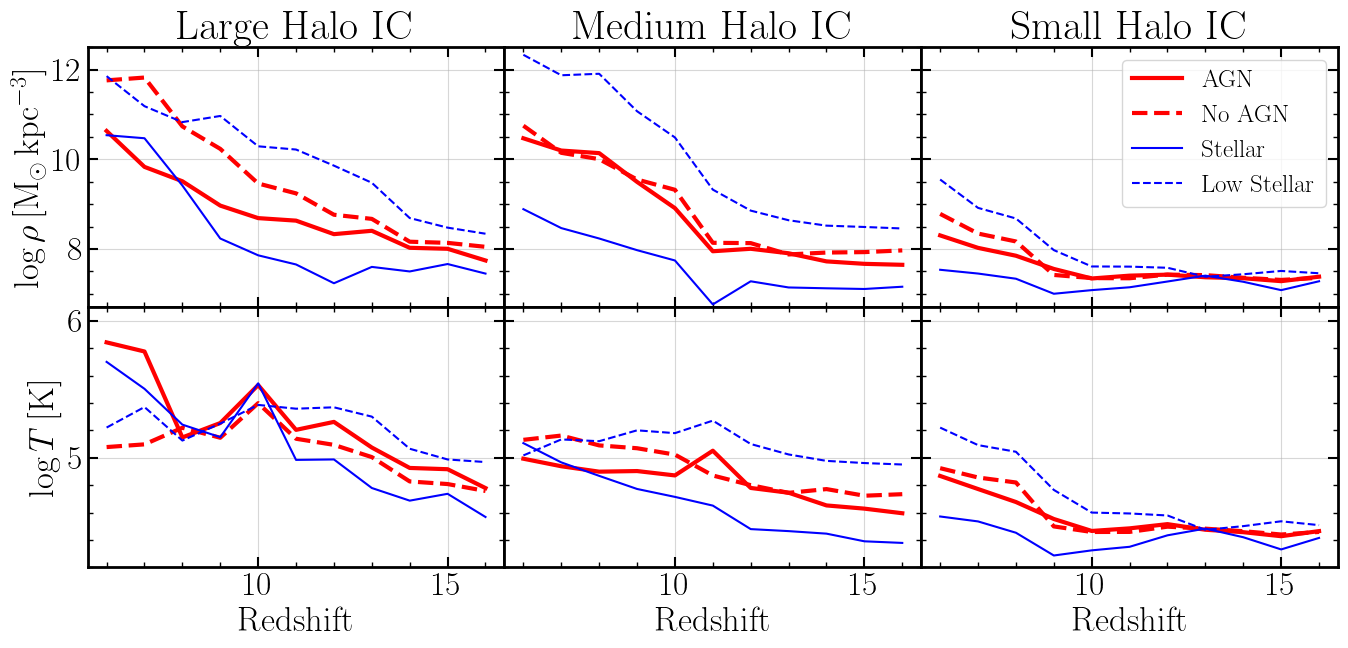

In [14]:
fig, axs = plt.subplots(2, 3, sharex=True, figsize=(14, 7))

AGN_lw = 3

# ---------- Row 1: BH Density ----------
axs[0,0].plot(redshifts, np.mean(BH_rho['C'][AGN], axis=0), color='red',lw = AGN_lw)
axs[0,0].plot(redshifts, np.mean(BH_rho['C'][noAGN], axis=0), color='red', ls='--',lw = AGN_lw)
axs[0,0].plot(redshifts, np.mean(BH_rho['C'][stellar_C], axis=0), color='blue')
axs[0,0].plot(redshifts, np.mean(BH_rho['C'][nostellar_C], axis=0), color='blue', ls='--')

axs[0,1].plot(redshifts, np.mean(BH_rho['Z'][AGN], axis=0), color='red',lw = AGN_lw)
axs[0,1].plot(redshifts, np.mean(BH_rho['Z'][noAGN], axis=0), color='red', ls='--',lw = AGN_lw)
axs[0,1].plot(redshifts, np.mean(BH_rho['Z'][stellar_Z], axis=0), color='blue')
axs[0,1].plot(redshifts, np.mean(BH_rho['Z'][nostellar_Z], axis=0), color='blue', ls='--')

axs[0,2].plot(redshifts, np.mean(BH_rho['L'][AGN], axis=0), color='red', label='AGN',lw = AGN_lw)
axs[0,2].plot(redshifts, np.mean(BH_rho['L'][noAGN], axis=0), color='red', ls='--', label='No AGN',lw = AGN_lw)
axs[0,2].plot(redshifts, np.mean(BH_rho['L'][stellar_L], axis=0), color='blue', label='Stellar')
axs[0,2].plot(redshifts, np.mean(BH_rho['L'][nostellar_L], axis=0), color='blue', ls='--', label='Low Stellar')


# ---------- Row 2: Mean Temperature ----------
axs[1,0].plot(redshifts, np.mean(Mean_temps['C'][AGN], axis=0), color='red',lw = AGN_lw)
axs[1,0].plot(redshifts, np.mean(Mean_temps['C'][noAGN], axis=0), color='red', ls='--',lw = AGN_lw)
axs[1,0].plot(redshifts, np.mean(Mean_temps['C'][stellar_C], axis=0), color='blue')
axs[1,0].plot(redshifts, np.mean(Mean_temps['C'][nostellar_C], axis=0), color='blue', ls='--')

axs[1,1].plot(redshifts, np.mean(Mean_temps['Z'][AGN], axis=0), color='red',lw = AGN_lw)
axs[1,1].plot(redshifts, np.mean(Mean_temps['Z'][noAGN], axis=0), color='red', ls='--',lw = AGN_lw)
axs[1,1].plot(redshifts, np.mean(Mean_temps['Z'][stellar_Z], axis=0), color='blue')
axs[1,1].plot(redshifts, np.mean(Mean_temps['Z'][nostellar_Z], axis=0), color='blue', ls='--')

axs[1,2].plot(redshifts, np.mean(Mean_temps['L'][AGN], axis=0), color='red',lw = AGN_lw)
axs[1,2].plot(redshifts, np.mean(Mean_temps['L'][noAGN], axis=0), color='red', ls='--',lw = AGN_lw)
axs[1,2].plot(redshifts, np.mean(Mean_temps['L'][stellar_L], axis=0), color='blue')
axs[1,2].plot(redshifts, np.mean(Mean_temps['L'][nostellar_L], axis=0), color='blue', ls='--')

# ---------- Labels & titles ----------
axs[0,0].set_title('Large Halo IC',fontsize=30)
axs[0,1].set_title('Medium Halo IC',fontsize=30)
axs[0,2].set_title('Small Halo IC',fontsize=30)

axs[0,0].set_ylabel(r'$\log \rho\,[\rm M_\odot\,kpc^{-3}]$',fontsize=25)
axs[1,0].set_ylabel(r'$\log T\,[\rm K]$',fontsize=25)

for ax in axs[0]:
    ax.set_ylim(6.7,12.5)
    ax.grid(alpha=0.5)
    if ax != axs[0][0]:
        ax.tick_params(labelleft=False)

for ax in axs[1]:
    ax.set_xlabel('Redshift',fontsize=25)
    ax.set_ylim(4.2,6.1)
    ax.grid(alpha=0.5)
    if ax != axs[1][0]:
        ax.tick_params(labelleft=False)

# Legend 
axs[0,2].legend(fontsize=18)

fig.tight_layout()
fig.subplots_adjust(hspace=0,wspace=0)
fig.savefig('Plots/Big_T_rho_rotated_samey.png')
